# 🤙 ASL Alphabet Recognition — Transfer Learning with MobileNetV2
This notebook trains an ASL (A–Z) classifier using MobileNetV2 and exports it to TensorFlow.js.

**Dataset:** [Kaggle ASL Alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)  
**Model:** MobileNetV2 (pretrained on ImageNet) + custom classification head  
**Output:** A `tfjs_model/` folder ready for your web app

## 1. 📦 Install Dependencies

In [3]:
!pip install tensorflow tensorflowjs kaggle matplotlib scikit-learn seaborn

  Using cached tensorflowjs-4.22.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached kaggle-2.0.0-py3-none-any.whl.metadata (15 kB)
  Using cached flax-0.12.6-py3-none-any.whl.metadata (11 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached jax-0.9.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.9.2-cp313-cp313-win_amd64.whl.metadata (1.4 kB)
  Using cached tensorflow_decision_forests-1.8.1.tar.gz (15.2 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached optax-0.2.8-py3-none-any.whl.metadata (7.9 kB)
  Using cached orbax_checkpoint-0.11.33-py3-none-any.whl.metadata (2.7 kB)
  Using cached tensorstore-0.1.82-cp313-cp313-win_amd64.whl.metadata (3.3 kB)
  Using cached treescope-0.1.10-py3-none-any.whl.metadata (6.6 kB)
  Using cached orbax_export-0.0.8-py3-none-any.whl.metadata (1.8 kB)
  Using cached d

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "C:\Users\Acer-Swift\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Users\Acer-Swift\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\Acer-Swift\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\Acer-Swift\AppData\Local\Temp\pip-build-env-gpnk50iv\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_build_whe

## 2. 📥 Download Dataset from Kaggle

> **Before running:** Upload your `kaggle.json` API token.  
> Get it from: https://www.kaggle.com/settings → API → Create New Token

In [4]:
import os

# --- Option A: Upload kaggle.json manually (Google Colab) ---
# from google.colab import files
# files.upload()  # upload your kaggle.json here

# Setup Kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download & unzip the ASL Alphabet dataset
!kaggle datasets download -d grassknoted/asl-alphabet
!unzip -q asl-alphabet.zip -d asl_dataset

print('✅ Dataset downloaded!')

'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


'kaggle' is not recognized as an internal or external command,
operable program or batch file.


✅ Dataset downloaded!


'unzip' is not recognized as an internal or external command,
operable program or batch file.


## 3. 🔍 Explore the Dataset

Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Images per class (sample): 3000 images


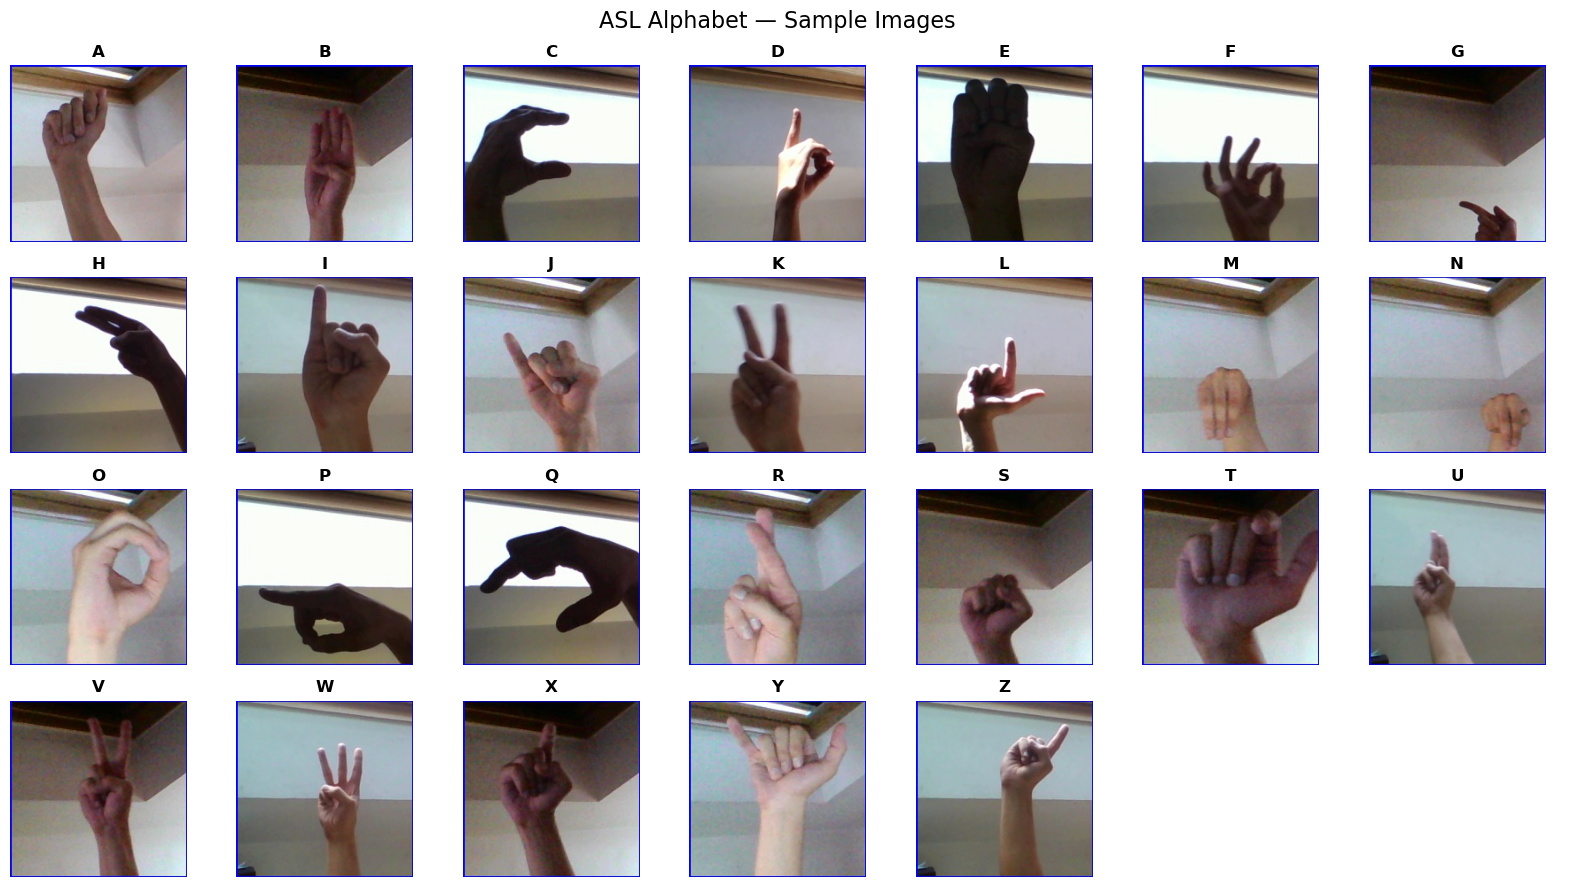

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

TRAIN_DIR = 'dataset/asl_alphabet_train/asl_alphabet_train'
TEST_DIR  = 'dataset/asl_alphabet_test/asl_alphabet_test'

# Only keep A–Z classes (exclude 'space', 'del', 'nothing')
CLASSES = sorted([c for c in os.listdir(TRAIN_DIR) if len(c) == 1 and c.isalpha()])
NUM_CLASSES = len(CLASSES)

print(f'Classes ({NUM_CLASSES}): {CLASSES}')
print(f'Images per class (sample): {len(os.listdir(os.path.join(TRAIN_DIR, CLASSES[0])))} images')

# Show sample images
fig, axes = plt.subplots(4, 7, figsize=(16, 9))
for ax, cls in zip(axes.flatten(), CLASSES):
    folder = os.path.join(TRAIN_DIR, cls)
    img_path = os.path.join(folder, random.choice(os.listdir(folder)))
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.axis('off')
for ax in axes.flatten()[len(CLASSES):]:
    ax.axis('off')
plt.suptitle('ASL Alphabet — Sample Images', fontsize=16)
plt.tight_layout()
plt.show()

## 4. ⚙️ Configuration

In [6]:
# ── Hyperparameters ───────────────────────────────────────────────
IMG_SIZE    = 224          # MobileNetV2 expects 224x224
BATCH_SIZE  = 32
EPOCHS_HEAD = 10           # Phase 1: train head only
EPOCHS_FINE = 10           # Phase 2: fine-tune top layers
LR_HEAD     = 1e-3
LR_FINE     = 1e-5
VAL_SPLIT   = 0.15
SEED        = 42
MODEL_SAVE  = 'asl_mobilenetv2.keras'
TFJS_DIR    = 'tfjs_model'

print('✅ Config set.')

✅ Config set.


## 5. 🔄 Data Pipeline

In [7]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# Build class-filtered dataset from TRAIN_DIR
# We point image_dataset_from_directory at the parent and filter by class names
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASSES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED
)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASSES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED
)

# Save class names in order — we'll need this in the webapp!
CLASS_NAMES = train_ds.class_names
print('Class order:', CLASS_NAMES)

# Augmentation for training
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='augmentation')

# Preprocess: normalize to [0,1] then apply MobileNetV2 preprocessing
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def prepare_train(ds):
    return (
        ds
        .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
        .map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
        .cache()
        .shuffle(1000)
        .prefetch(AUTOTUNE)
    )

def prepare_val(ds):
    return (
        ds
        .map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(AUTOTUNE)
    )

train_data = prepare_train(train_ds)
val_data   = prepare_val(val_ds)

print('✅ Data pipeline ready.')

Found 78000 files belonging to 26 classes.
Using 66300 files for training.
Found 78000 files belonging to 26 classes.
Using 11700 files for validation.
Class order: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
✅ Data pipeline ready.


## 6. 🏗️ Build the Model (MobileNetV2 + Custom Head)

In [ ]:
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 base — frozen initially
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base for Phase 1

# Custom classification head
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs, name='ASL_MobileNetV2')
model.summary()

print(f'\n✅ Model built — {NUM_CLASSES} output classes')

Model: "ASL_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,051,866 (11.64 MB)

 Trainable params: 793,882 (3.03 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


✅ Model built — 26 output classes


: 

## 7. 🚀 Phase 1 — Train the Head (Frozen Base)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
]

print('🔥 Phase 1: Training head only...')
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_phase1
)

🔥 Phase 1: Training head only...
Epoch 1/10


## 8. 🔓 Phase 2 — Fine-Tune Top Layers of Base

In [ ]:
# Unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print(f'Fine-tuning from layer {fine_tune_from} / {len(base_model.layers)}')
print(f'Trainable layers: {sum(1 for l in model.layers if l.trainable)}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=3, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE, save_best_only=True, verbose=1),
]

print('🔥 Phase 2: Fine-tuning...')
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FINE,
    callbacks=callbacks_phase2
)

## 9. 📊 Training Curves

In [ ]:
import matplotlib.pyplot as plt

def plot_history(h1, h2):
    acc  = h1.history['accuracy']  + h2.history['accuracy']
    val  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    vloss= h1.history['val_loss'] + h2.history['val_loss']
    ep   = range(1, len(acc) + 1)
    split= len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep, acc, label='Train Accuracy')
    ax1.plot(ep, val, label='Val Accuracy')
    ax1.axvline(split, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
    ax1.legend()

    ax2.plot(ep, loss, label='Train Loss')
    ax2.plot(ep, vloss, label='Val Loss')
    ax2.axvline(split, color='gray', linestyle='--', label='Fine-tune start')
    ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
    ax2.legend()

    plt.suptitle('Training History — Phase 1 + Phase 2', fontsize=14)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_history(history1, history2)

## 10. 🧪 Evaluate on Test Set

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Build test dataset
test_ds = image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASSES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_data = prepare_val(test_ds)

# Predict
y_true, y_pred = [], []
for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=0.3)
plt.title('Confusion Matrix — ASL A-Z', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 11. 💾 Save Class Names (for the Web App)

In [ ]:
import json

with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

print('Class names saved to class_names.json:')
print(CLASS_NAMES)

## 12. 🌐 Export to TensorFlow.js

In [ ]:
import tensorflowjs as tfjs

# Load the best saved model
best_model = tf.keras.models.load_model(MODEL_SAVE)

# Convert and save
tfjs.converters.save_keras_model(best_model, TFJS_DIR)

print(f'✅ TensorFlow.js model exported to: ./{TFJS_DIR}/')
print('Files:')
for f in sorted(os.listdir(TFJS_DIR)):
    size = os.path.getsize(os.path.join(TFJS_DIR, f))
    print(f'  {f:40s} {size/1024:.1f} KB')

## 13. 🗜️ (Optional) Quantize for Smaller File Size

In [ ]:
# Float16 quantization — cuts model size ~50% with minimal accuracy loss
tfjs.converters.save_keras_model(
    best_model,
    TFJS_DIR + '_float16',
    quantization_dtype_map={'float16': '*'}
)

print('✅ Float16 quantized model saved to:', TFJS_DIR + '_float16')

## ✅ Summary — What to Copy to Your Web App

| File / Folder | Purpose |
|---|---|
| `tfjs_model/model.json` | Model architecture |
| `tfjs_model/*.bin` | Model weights |
| `class_names.json` | Label index → letter mapping |
| `training_curves.png` | Training visualization |
| `confusion_matrix.png` | Per-class accuracy |

Place the `tfjs_model/` folder and `class_names.json` in your web app directory and load them with:
```javascript
const model = await tf.loadLayersModel('./tfjs_model/model.json');
const classes = await fetch('./class_names.json').then(r => r.json());
```